<a href="https://colab.research.google.com/github/SotaYoshida/Lecture_DataScience/blob/master/Python_chapter7_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#最適化問題の基礎

学問領域に留まらず、世の中の多くの問題は、最適化問題に帰着される.

大雑把に言えば「ある量の最小値/最大値と、それを与える変数(パラメータや条件と言っても良い)の値を知ること」と言い換えられる. 

この章では、関数の最適化の初歩について、プログラムを動かしながら学んでいくこととする。

* 高校で微分をあまり勉強していないという方に向けて末尾に数学的準備の項を設けてあります(よく知っているという方もぜひさっと目を通してみてください).

##考えたい問題のイメージ

以下で考えたい問題のポンチ絵です

## 勾配の計算について

###  解析的に微分が計算できる場合


たとえば以下の例  
例1: $f(x)= \sum^p_{i=0} a_i x^i$ (多項式)  
例2: $f(x)= \exp{(-ax^2+bx+c)}$ (指数関数)  
例3: $f(x)= \ln{x}$ (自然対数)  

のように
1. $f(x)$が閉じた形で書き下せる
2. 興味のある区間(定義域)で微分が計算でき、有限の値を持つ場合

$x$をその微分した表式に代入することで実装が可能です.  
([有限の値をもつ場合]と限定したのは、微分が発散してしまうとパラメータの更新には意味をなさないため)

(大量の関数を考えて微分した表式が必要な場合は、いちいち関数の微分形を導出してコードにするのは面倒なので、Sympyなどのモジュールを使うのも一つの手です)


データをみて自分でモデルを立てて解析する場合というのは、これに相当します。

### 数値的に勾配を計算する場合

$f(x)$が具体的な$x$の形で書き下せない場合もあります.

たとえば「$f(x)$が条件$x$のもとで行った何らかの測定結果である場合」などがこれにあてはまります。

より具体的な例をあげるなら、
あなたはとある医療薬品の効果(数値で表現できると仮定)を調べる研究をしているとして、温度$x$を変えながら何回か測定して$f(x)$の値を得るような状況を想像してください.

このような場合、関数$f(x)$の具体的な表式がわからないので、勾配だって$x$に対する式として書きくだすことはできません。

しかし、微分の定義に立ち返って考えてみると、
$f(x=a)$の値と、$x=a$から微小量$\delta$だけ動かした場所での値$f(x+\delta)$がわかっていれば$f'(x=a)$を計算することができます。
つまり細かく$x$を調整することができれば、原理的には勾配の情報を手に入れることができます。

ただし、上の絵のように$\delta$があまりにも大きくなってしまうと、正しく勾配が計算できない一方で、$x$を調整する精度や、勾配を計算する際のコンピュータの数値精度には限りがありますので、文字通りの意味で"無限小"の$\delta$を考えることはできず、有限の小さな値で$\delta$を表現することになり、それにより数値計算に大きな誤差が紛れ込む危険性もあります。

「関数の変動(変化の度合い)がものすごく大きいと、数値微分の精度は$\delta$に対する依存性が強くなる」といって伝わるでしょうか？



##代表的な最適化手法

### 勾配降下法

### Adam

## 数学的準備: 勾配の計算に関して

日本では、中学校(2年?)で傾きと切片を学習する。

ある直線$y=ax+b$を考えたとき、直線の傾き$a$に着目すれば、$x$の増加分に対して$y$がどれだけ変化するかを知ることができる。

一方、実社会で扱うデータは、一般に直線よりも複雑な形をしていて、それを式で表現しようと思うと、様々な関数の形を考える必要がある。(たとえば何かの値の季節変動などをイメージしてください)

したがって、直線の場合の[傾き]を、直線以外の関数に"拡張"しようと考えるのは至って自然な発想といえる.それが**微分**の概念である.

微分(積分)の歴史は古く、人類史のどの時点でアイデアが確立したとするかは諸説あるが、最も代表的なものは、17世紀にニュートンとライプニッツが確立したとする説である.

ニュートンは、微分の概念を独自に定式化し天体の軌道などを予測するなどの偉大な功績を残した.

以下の内容は、全学向けの授業ということもあって厳密性はかなり犠牲にして微分の概念を導入している(もちろん、大学の数学の教科書に載っている関数の連続性や微分の厳密な定義は非常に重要です).



### 微分の基本的な考え方

定義: ある変数$x$について関数$f(x)$が与えられているとき、関数$f(x)$の$x=a$での微分を$f'(a)=\lim_{\delta \to 0} \frac{f(a+\delta)-f(a)}{\delta}$と定義する.  
ここで、$\lim_{\delta \to 0}$は0に限りなく近い(無限小)の$\delta$を考えることを意味する。  
(以下では、微分の値のことを指して勾配と言ったりもします)

つまり、関数をある点からちょこっとだけ動かしたときに、どれだけ関数の値が変動しますか？ということです。"傾き"っぽいですよね？

**直線の例**  
$f(x) = ax + b $の$x=x_1$での微分値は定義に当てはめて計算すると
$f'(x_1)= \lim_{\delta \to 0} \frac{f(x_1+\delta)-f(x_1)}{\delta}= \lim_{\delta \to 0} \frac{(a(x_1+\delta)+b)-(ax_1+b)}{\delta} = a $ となる。
つまり微分の値は直線の傾きに対応していて、なおかつ微分の値はどこの場所($x$)で調べても定数$a$であることを意味している。


**二次関数(放物線)の例**  
$f(x) = ax^2 + bx +c $
の$x=x_1$での微分は、定義にならって計算すると
$f'(x_1) = 2ax_1+b$となる(確かめてみよう)  
一方で$f(x)$を平方完成すると$f(x)=a(x+\frac{b}{2a})^2 -\frac{b^2}{4a} +c$となり、$x=-b/(2a)$で傾きが0になる。  
つまりこの二次関数は$x=-b/(2a)$で極値($a>0$なら最小値, $a<0$なら最大値)を持つ。
$a$が$x$が$x_1$よりも大きければ
微分の値は$x_1=-b/(2a)$のとき、値は0になっている.


つまり、微分が0というのは関数の形がそこで谷や峠になっていることを意味する。





a=2.0,b=4.0,c=5.0とでもして、図をかいてみよう

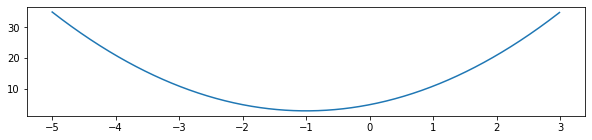

In [2]:
from matplotlib import pyplot as plt
import numpy as np
xr = np.arange(-5.0,3.0,0.01)
yr = 2.0 * xr**2 + 4.0 * xr + 5.0
fig = plt.figure(figsize=(10,2))
plt.plot(xr,yr)
plt.show()

確かに$x=-b/(2a)=-1.0$のところで極値(最小値)となっている。

微分の値もplotしてみると

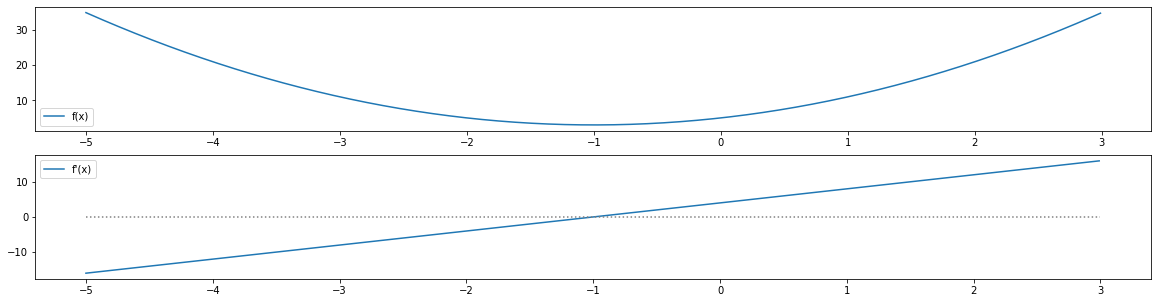

In [9]:
xr = np.arange(-5.0,3.0,0.01)
yr = 2.0 * xr**2 + 4.0 * xr + 5.0
yp = 4.0 * xr + 4.0 
fig = plt.figure(figsize=(20,5))
axs = [fig.add_subplot(211),fig.add_subplot(212)]
axs[0].plot(xr,yr,label="f(x)"); axs[0].legend()
axs[1].plot(xr,yp,label="f'(x)");axs[1].plot([-5,3],[0,0],color="gray",linestyle="dotted");axs[1].legend()
plt.show();plt.close()

$x<-1$では$f'(x)<0$で、$x>-1$では$f'(x)>0$となっていますね。

これまでは、定義に即して微分の値を計算していましたが、毎回調べたい点で定義に立ち返るというのは面倒です。

関数が閉じた形で与えられているとき(つまり、$f(x)$が$x$の具体的な表式で与えられているとき)、基本的にはその微分$f'(x)$も$x$の関数として書き下すことができます。

そうすれば、好きな点で$x$を代入すれば値$f(x),f'(x)$を知ることができます。


とりあえずは以下を公式的に抑えておけば問題は有りません。

1. $x$の$x$に対する微分は1
2. $a x^p$の$x$に対する微分は$ax^{p-1}$ (xのべきが1下がる)
3. $\exp{(x)}$(ネイピア数$e$の$x$乗)の$x$に対する微分は$\exp{(x)}$ 
4. $\cos{x}$の$x$に対する微分は$-\sin{x}$
5. $\sin{x}$の$x$に対する微分は$\cos{x}$
6. $\ln{x}$の$x$に対する微分は$1/x$

いずれも、上の微分の定義や、指数関数/三角関数/対数関数の定義(c.f. マクローリン展開)から証明することができますので、興味があれば人生で一度はやってみてください。
